# Self-Diffusion in Oxide-Glass Melts — MSD Tutorial

Measure **atomic self-diffusion** in an oxide melt with **amorphouspy**: run an MD trajectory with a
compact **log-then-linear** dump schedule, compute the mean-squared displacement (MSD), extract
per-species diffusion coefficients, save the trajectory, and fit the temperature dependence.

---

## Physical background

### MSD & the Einstein relation

$$
\mathrm{MSD}(t) = \big\langle |\mathbf{r}_i(t) - \mathbf{r}_i(0)|^2 \big\rangle = 2\,d\,D\,t
\qquad (d=3 \Rightarrow \mathrm{MSD} = 6 D t).
$$

`diffusion_simulation` dumps on a **decade-log** schedule below `crossover_ps` (steps 1, 2, …, 9, 10,
20, …, 90, 100, …) and **linearly** above it. This keeps the trajectory small; because the samples are
non-uniform in time the MSD is computed **single-origin** (referenced to the first frame).

### Arrhenius:  $D(T) = D_0 \exp(-E_a / k_\mathrm{B} T)$

## 1. Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from executorlib import SingleNodeExecutor

from amorphouspy import (
    diffusion_simulation,
    generate_potential,
    get_ase_structure,
    get_diffusion,
    get_structure_dict,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 300
colors = {"Na": "tab:blue", "Si": "tab:orange", "O": "tab:green"}

## 2. System setup

A small **Na$_2$O–SiO$_2$** melt (30 mol% Na$_2$O) with the PMMCS potential. Na is the mobile modifier;
Si and O form the network.

In [2]:
with SingleNodeExecutor(plot_dependency_graph=False) as exe:
    atoms_dict = exe.submit(
        get_structure_dict, composition={"Na2O": 25, "SiO2": 75}, target_atoms=300, mode="molar"
    ).result()
    structure = exe.submit(get_ase_structure, atoms_dict=atoms_dict).result()
    potential = exe.submit(generate_potential, atoms_dict=atoms_dict, potential_type="pmmcs").result()

print(f"Atoms   : {len(structure)}")
print(f"Species : {sorted(set(structure.get_chemical_symbols()))}")

Atoms   : 300
Species : ['Na', 'O', 'Si']


## 3. Run a diffusion simulation and save the trajectory

`diffusion_simulation` equilibrates at constant volume, runs the production stage on the log-then-linear
dump schedule, computes the MSD/diffusion, and (with `save_trajectory=...`) writes a **gzipped extXYZ**
trajectory that can be reloaded later.

> **Demo settings** are small so the notebook runs quickly; for production use the defaults
> (`equilibration_steps=100_000`, `production_steps>=1_000_000`, `crossover_ps=100`).

In [3]:
# traj_path = "diffusion_traj.xyz.gz"
with SingleNodeExecutor() as exe:
    out = exe.submit(
        diffusion_simulation,
        structure=structure,
        potential=potential,
        temperature_sim=3000.0,
        equilibration_steps=10_000,  # demo
        production_steps=100_000,  # demo
        crossover_ps=10.0,  # log below 10 ps
        points_per_decade=9,  # 1,2,...,9,10,20,...,90,100,...
        linear_interval_ps=5.0,  # linear (5 ps) above the crossover
        save_trajectory=None,  # demo
        server_kwargs={"cores": 1},
    ).result()

n_uniform = 100_000 // 100 + 1
print(f"frames kept      : {len(out['frames'])}  (a uniform dump every 100 steps would be ~{n_uniform})")
# print(f"saved trajectory : {out['trajectory_path']}  ({Path(traj_path).stat().st_size / 1024:.0f} KB)")

/pl_l33/msa/work/gitub_repositories/amorphouspy/amorphouspy/src/amorphouspy/properties/diffusion.py:374: UserWarning: MSD log-log slope 0.70 over the fit window deviates from 1; the trajectory may not be in the diffusive regime (extend the run or shift the fit window).
  output["per_species"] = {symbol: _one(msd) for symbol, msd in msd_result["msd_per_species"].items()}
/pl_l33/msa/work/gitub_repositories/amorphouspy/amorphouspy/src/amorphouspy/properties/diffusion.py:374: UserWarning: MSD log-log slope 0.75 over the fit window deviates from 1; the trajectory may not be in the diffusive regime (extend the run or shift the fit window).
  output["per_species"] = {symbol: _one(msd) for symbol, msd in msd_result["msd_per_species"].items()}


frames kept      : 56  (a uniform dump every 100 steps would be ~1001)


## 4. Mean-squared displacement

Log–log MSD with markers on each dumped frame — dense (decade-log) at short times, then the uniform
tail above the 5 ps crossover.

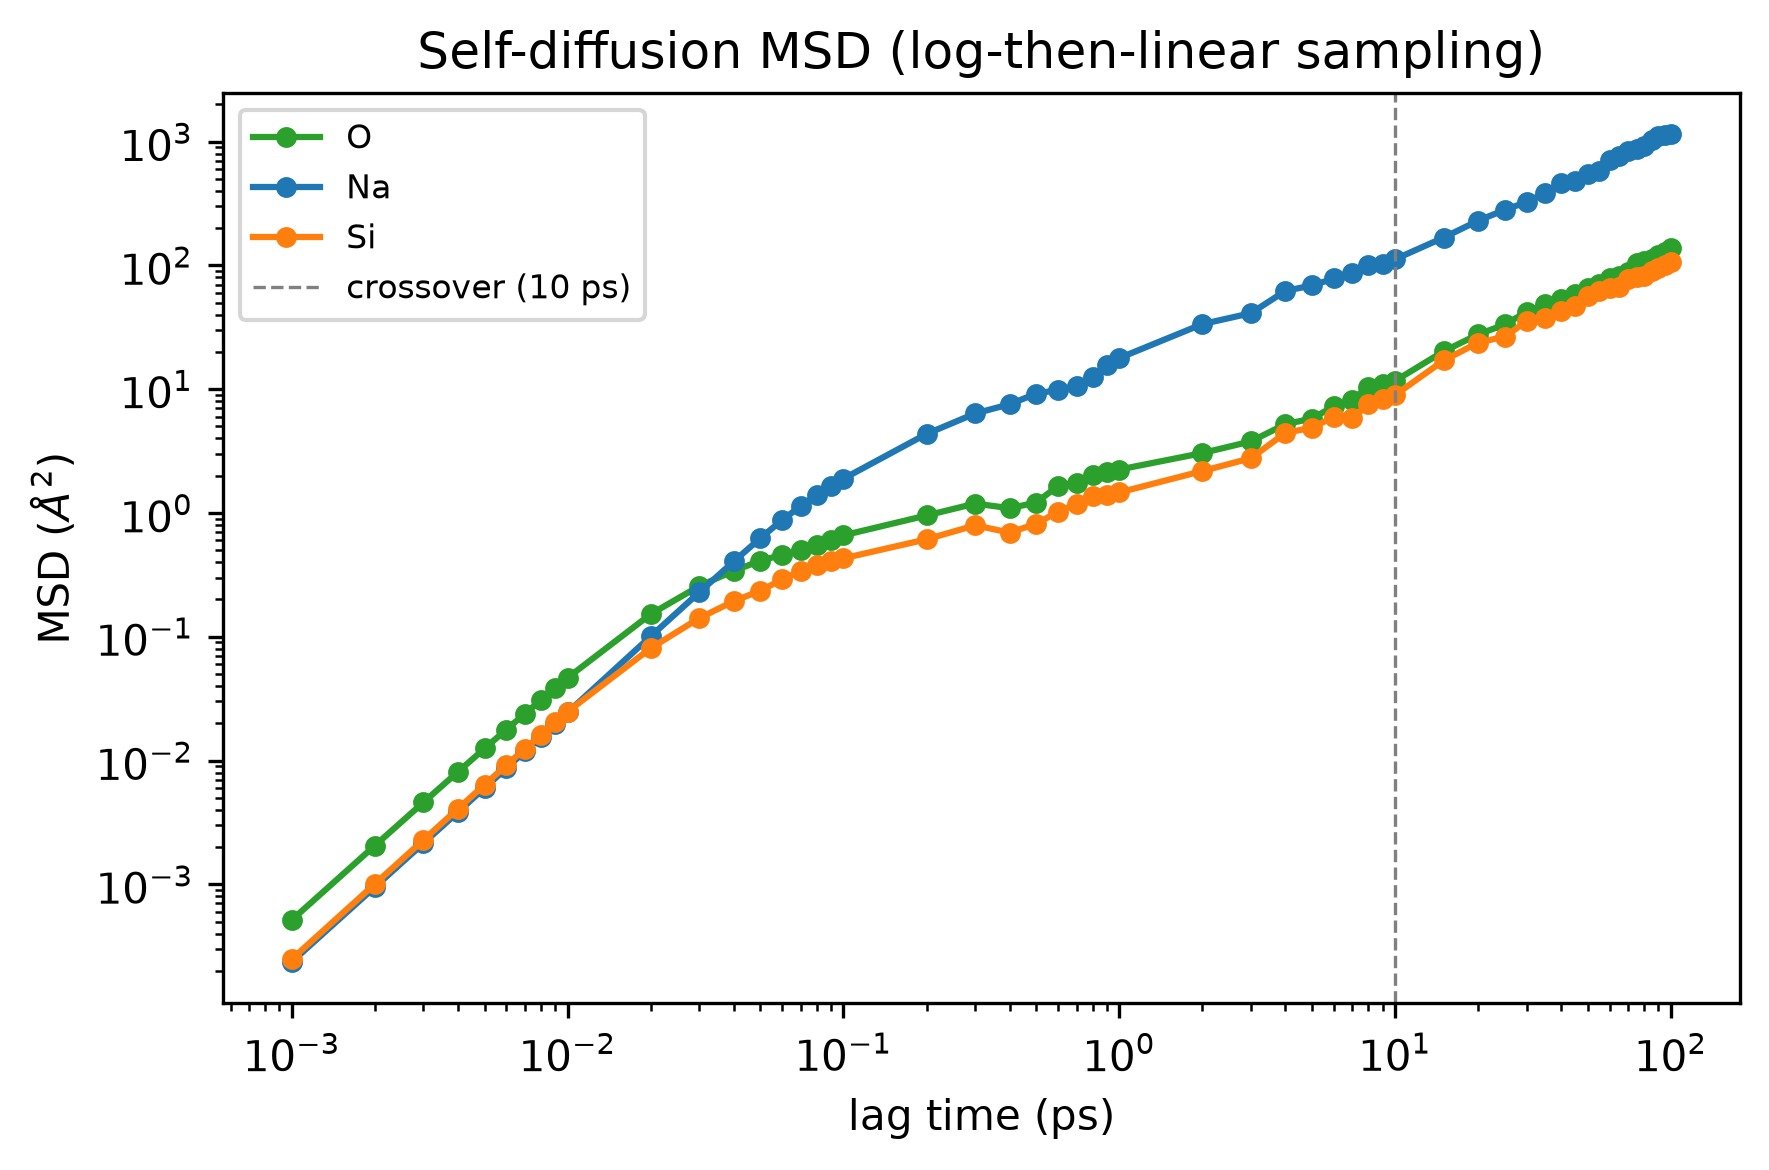

In [4]:
msd = out["msd"]
lag = np.array(msd["lag_time_ps"])
species = list(msd["msd_per_species"])

fig, ax = plt.subplots(figsize=(6, 4))
for sp in species:
    ax.loglog(lag[1:], np.array(msd["msd_per_species"][sp])[1:], "o-", ms=4, label=sp, color=colors.get(sp))
ax.axvline(10.0, color="grey", ls="--", lw=0.8, label="crossover (10 ps)")
ax.set(xlabel="lag time (ps)", ylabel=r"MSD ($\AA^2$)", title="Self-diffusion MSD (log-then-linear sampling)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Self-diffusion coefficients

`get_diffusion` fits the diffusive window; `loglog_slope` near 1 confirms the diffusive regime.

In [5]:
diffusion = out["diffusion"]
print(f"{'species':8} {'D (cm^2/s)':>14} {'log-log slope':>14}")
for sp in species:
    e = diffusion["per_species"][sp]
    print(f"{sp:8} {e['diffusion_cm2_s']:>14.3e} {e['loglog_slope']:>14.2f}")

species      D (cm^2/s)  log-log slope
O             1.998e-05           0.71
Na            1.719e-04           0.95
Si            1.629e-05           0.77


## 6. Temperature scan — MSD and Arrhenius

Running `diffusion_simulation` at several temperatures gives $D(T)$. The **left** panel overlays the Na
MSD at each temperature (steeper at higher $T$); the **right** panel fits $\ln D$ vs $1/T$ to extract the
activation energy $E_a$. We run a small **real** scan (the same structure, re-equilibrated at each
temperature).

```python
scan_temperatures = [1500.0, 2000.0, 2500.0, 3000.0, 3500.0, 4000.0]

d_na_scan, msd_scan = [], []
with SingleNodeExecutor() as exe:
    for temperature in scan_temperatures:
        res = exe.submit(
            diffusion_simulation,
            structure=structure,
            potential=potential,
            temperature_sim=temperature,
            equilibration_steps=50_000,   # demo
            production_steps=1_000_000,     # demo
            crossover_ps=10.0,
            points_per_decade=9,
            linear_interval_ps=10.0,
            server_kwargs={"cores": 2},
        ).result()
        d_na_scan.append(res["diffusion"]["per_species"]["Na"]["diffusion_cm2_s"])
        msd_scan.append(res["msd"])
        print(f"T = {temperature:6.0f} K   D_Na = {d_na_scan[-1]:.3e} cm^2/s")

temperatures = np.array(scan_temperatures)
d_na = np.array(d_na_scan)
(d0, ea_ev), _ = fit_arrhenius(temperatures, d_na)
print(f"\nArrhenius fit:  D0 = {d0:.3e} cm^2/s,  Ea = {ea_ev:.3f} eV")

kb = 8.617333262e-5
tcolors = plt.cm.viridis(np.linspace(0.0, 0.85, len(scan_temperatures)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: Na MSD at each temperature
for temperature, msd_t, color in zip(scan_temperatures, msd_scan, tcolors):
    lag = np.array(msd_t["lag_time_ps"])
    ax1.loglog(lag[1:], np.array(msd_t["msd_per_species"]["Na"])[1:], "o-", ms=3, color=color, label=f"{temperature:.0f} K")
ax1.set(xlabel="lag time (ps)", ylabel=r"Na MSD ($\AA^2$)", title="Na MSD vs temperature")
ax1.legend(fontsize=8)

# Right: Arrhenius fit
ax2.semilogy(1000 / temperatures, d_na, "o", ms=7, color="tab:red", label="simulation")
fit_t = np.linspace(temperatures.min(), temperatures.max(), 100)
ax2.semilogy(1000 / fit_t, d0 * np.exp(-ea_ev / (kb * fit_t)), "-", color="k", label=f"Arrhenius (Ea = {ea_ev:.2f} eV)")
ax2.set(xlabel="1000 / T  (1/K)", ylabel=r"$D_\mathrm{Na}$ (cm$^2$/s)", title="Arrhenius plot")
ax2.legend()
fig.tight_layout()
plt.show()
```

```python
D_Na = np.asarray([31.6, 23.6, 17.7, 11.9, 9.16, 7.93, 6.86, 5.54, 3.73, 3.10])*1e-5
T_ref = [4000, 3500, 3000, 2500, 2250, 2100, 2000, 1850, 1600, 1500]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3.5*2, 3.5/1.3333), dpi=300)

# Left: Na MSD at each temperature
for temperature, msd_t, color in zip(scan_temperatures, msd_scan, tcolors):
    lag = np.array(msd_t["lag_time_ps"])
    ax1.loglog(lag[1:], np.array(msd_t["msd_per_species"]["Na"])[1:], "o-", ms=3, color=color, label=f"{temperature:.0f} K")
ax1.set(xlabel="lag time (ps)", ylabel=r"Na MSD ($\AA^2$)")
ax1.legend(fontsize=8)

# Right: Arrhenius fit
ax2.semilogy(1000 / temperatures, d_na, "o", ms=7, color="tab:red", label="simulation")
ax2.semilogy(1000 / np.array(T_ref), D_Na, "s", ms=5, color="tab:blue", label="literature")
fit_t = np.linspace(temperatures.min(), temperatures.max(), 100)
ax2.semilogy(1000 / fit_t, d0 * np.exp(-ea_ev / (kb * fit_t)), "-", color="k", label=f"(Ea = {ea_ev:.2f} eV)")
ax2.set(xlabel="1000 / T  (1/K)", ylabel=r"$D_\mathrm{Na}$ (cm$^2$/s)")
ax2.legend()
fig.tight_layout()
plt.show()
```